<a href="https://colab.research.google.com/github/juannMGC/Trabajo-de-Grado/blob/main/PropuestaTGRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

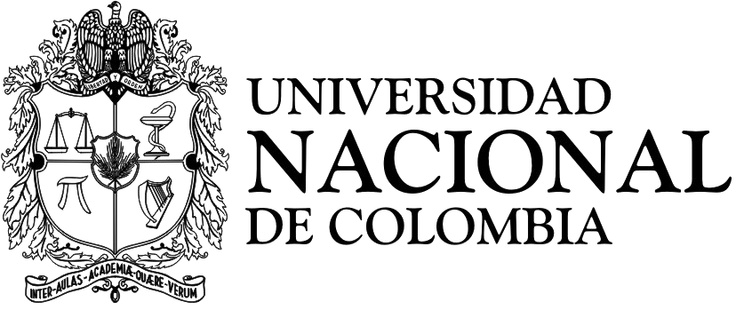
# **Proyecto Final: Machine Learning para predecir el impacto de la calidad del aire en la salud en Manizales.**

**Autor:** Juan Manuel Garcia Cifuentes

**Correo:** jugarciaci@unal.edu.co

In [ ]:
# LIBRERÍAS ESTÁNDAR
import joblib

#  MANIPULACIÓN DE DATOS
import numpy as np
import pandas as pd

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# PREPROCESAMIENTO
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RepeatedStratifiedKFold,
    cross_val_score
)

# MODELOS
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    AdaBoostClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# MÉTRICAS
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    r2_score
)

# BALANCEO
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [ ]:
df = pd.read_excel('BD_impacto_salud.xlsx')
df.head()

In [ ]:
hist = go.Figure(data=[go.Histogram(x=df['ClaseImpactoSalud'])])
hist.show()

In [ ]:
df.dropna(inplace=True)

In [ ]:
feature_list = df.columns.tolist()

In [ ]:
df = df.astype(float)

In [ ]:
df.dtypes

Imputacion de Valores NaN

In [ ]:
imputer = SimpleImputer(strategy='mean')

In [ ]:
df_new = imputer.fit_transform(df)

In [ ]:
df_new = pd.DataFrame(df_new)

In [ ]:
df_new.columns = feature_list

In [ ]:
df_new.head(10)

**Selección e ingeniería de características**

In [ ]:
df_new['ClaseImpactoSalud'].value_counts()

In [ ]:
df_new['ClaseImpactoSalud'] = df_new.sum(axis=1)/len(df_new.columns)

In [ ]:
df_new['ClaseImpactoSalud'] = df_new['ClaseImpactoSalud'].apply(lambda x: int(x))

In [ ]:
hist = go.Figure(data=[go.Histogram(x=df_new['ClaseImpactoSalud'])])
hist.show()

In [ ]:
df_new.head()

In [ ]:
df_new.sort_values(by='ClaseImpactoSalud', ascending=False)

In [ ]:
def clase_impacto_salud(score):
    if score <= 20:
        return "Muy bajo"
    elif score <= 40:
        return "Bajo"
    elif score <= 60:
        return "Moderado"
    elif score <= 80:
        return "Alto"
    else:
        return "Muy alto"

In [ ]:
df_new['new_ClaseImpactoSalud'] = df_new['ClaseImpactoSalud'].apply(lambda x: clase_impacto_salud(x))

In [ ]:
df_new.head(5)

In [ ]:
df_new['new_ClaseImpactoSalud'].value_counts()

In [ ]:
df_imbalance = df_new['new_ClaseImpactoSalud'].value_counts()

In [ ]:
df_imbalance = pd.DataFrame(df_imbalance).reset_index()
df_imbalance.columns = ['Class', 'Instances']
df_imbalance

**Data Imbalance**

In [ ]:
plt.subplots(figsize=(15,5))
sns.barplot(x='Class',y='Instances',data=df_imbalance)
plt.ylabel('Instances', fontsize=15)
plt.xticks(rotation=0,fontsize=12)
plt.xlabel('Class', fontsize=15)
plt.title('Class Imbalance', fontsize=20)
plt.show()

In [ ]:
fig = plt.figure(figsize = (15, 5))
sns.heatmap(df_new.drop(columns=['new_ClaseImpactoSalud']).corr(), annot=True)
plt.title('Pearson Correlation Heatmap')
plt.show()

In [ ]:
df_new = df_new[df_new.iloc[:, -1] != "Muy bajo"]

In [ ]:
X = df_new.iloc[:, : -1]
y = df_new.iloc[:, -1]

In [ ]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=3)

scaler = StandardScaler()
encoder = LabelEncoder()

In [ ]:
X_scaled = scaler.fit_transform(X)

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y, test_size=0.3, random_state=0)

In [ ]:
rfc.fit(xtrain, ytrain)
pred = rfc.predict(xtest)

In [ ]:
accuracy_score(ytest, pred)

In [ ]:
print(classification_report(ytest, pred))

In [ ]:
roc = roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')
print("ROC AUC:", round(roc, 4))

In [ ]:
f1_score(ytest, pred, average='weighted')

**Oversampling using SMOTE**

In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [ ]:
y_res.value_counts()

In [ ]:
X_res.shape

In [ ]:
X_scaled = scaler.fit_transform(X_res)
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y_res, test_size=0.3, random_state=0)
rfc = RandomForestClassifier(n_estimators=100, max_depth=3, n_jobs=-1, random_state=0)
rfc.fit(xtrain, ytrain)
pred = rfc.predict(xtest)
print('Accuracy: {}'.format(accuracy_score(ytest, pred)))
print('F1-Score: {}'.format(f1_score(ytest, pred, average='weighted')))
print(classification_report(ytest, pred))
# print('AUC score: {}'.format(roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')))

In [ ]:
plt.subplots(figsize=(15,5))
sns.barplot(x='Class',y='Instances',data=df_imbalance)
plt.ylabel('Instances', fontsize=15)
plt.xticks(rotation=0,fontsize=12)
plt.xlabel('Class', fontsize=15)
plt.title('Class Imbalance', fontsize=20)
plt.show()

**Oversampling + Stratified sampling**

In [ ]:
X_scaled = scaler.fit_transform(X_res)
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y_res, test_size=0.3, stratify=y_res, random_state=0)
rfc = RandomForestClassifier(n_estimators=150, max_depth=3, n_jobs=-1, random_state=0)
rfc.fit(xtrain, ytrain)
pred = rfc.predict(xtest)
print('Train Accuracy: {}'.format(accuracy_score(ytrain, rfc.predict(xtrain))))
print('Test Accuracy: {}'.format(accuracy_score(ytest, pred)))
print('F1-Score: {}'.format(f1_score(ytest, pred, average='weighted')))
print(classification_report(ytest, pred))
# print('AUC score: {}'.format(roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')))

In [ ]:
clf = AdaBoostClassifier(n_estimators=1000, random_state=0, learning_rate=2.2)
clf.fit(xtrain, ytrain)
pred = clf.predict(xtest)

In [ ]:
print('Train Accuracy: {}'.format(accuracy_score(ytrain, clf.predict(xtrain))))
print('Test Accuracy: {}'.format(accuracy_score(ytest, pred)))
print('F1-Score: {}'.format(f1_score(ytest, pred, average='weighted')))
print(classification_report(ytest, pred))
# print('AUC score: {}'.format(roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')))

**Creacion de pipeline**


In [ ]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)# Validación cruzada

ada = AdaBoostClassifier()
pipe_ada = Pipeline([('model', ada)])# Pipeline
scores_ada = cross_val_score(pipe_ada, X, y, scoring='accuracy', cv=cv, n_jobs=-1)# Evaluación

knn = KNeighborsClassifier()
pipe_knn = Pipeline([('scaler', scaler), ('model', knn)])
scores_knn = cross_val_score(pipe_knn, X,y, scoring= 'accuracy',cv =cv, n_jobs=-1)

rf = RandomForestClassifier()
pipe_rf = Pipeline([('model', rf)])
scores_rf = cross_val_score(pipe_rf, X,y, scoring= 'accuracy',cv =cv, n_jobs=-1)

mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=0)
pipe_mlp = Pipeline([('scaler', scaler), ('model', mlp)])
scores_mlp = cross_val_score(pipe_mlp, X,y, scoring= 'accuracy',cv =cv, n_jobs=-1)

**Selección de modelos y ajuste de hiperparámetros mediante GridSearchCV**

In [ ]:
model_params = {

    'Random Forest': {
        'model': pipe_rf,
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 8],
            'model__min_samples_split': [2, 5]
        }
    },

    'AdaBoost': {
        'model': pipe_ada,
        'params': {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.5, 1.0]
        }
    },

    'KNN': {
        'model': pipe_knn,
        'params': {
            'model__n_neighbors': [3, 5, 7],
            'model__p': [1, 2]
        }
    },

    'MLP': {
        'model': pipe_mlp,
        'params': {
            'model__hidden_layer_sizes': [(50,), (100,), (100,50)],
            'model__activation': ['relu', 'tanh'],
            'model__alpha': [0.0001, 0.001],
            'model__learning_rate_init': [0.001]
        }
    }
}

In [ ]:
model_scores = []

for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=cv, return_train_score=False, n_jobs=-1)
    clf.fit(xtrain, ytrain)
    ypred = clf.predict(xtest)
    model_scores.append({
        'Model': model_name,
        'Best parameters': clf.best_params_,
        'Train score': clf.best_score_,
        'Test score': accuracy_score(ytest, ypred)

    })

print(model_scores)

In [ ]:
bm = pd.DataFrame(model_scores)
bm = bm.sort_values(by='Test score', ascending=False)
bm

In [ ]:
colors = ['lightslategray',] * 5
colors[1] = 'crimson'

y = round(bm['Test score'], 4)
x = bm['Model']

# Use textposition='auto' for direct text
fig = go.Figure(data=[go.Bar(
            x=x, y=y,
            text=y,
            textposition='outside', orientation = 'v', marker_color=colors
        )])

# fig.update_layout(
#     autosize=False,
#     width=800,
#     height=500)

fig.update_layout(title_text='Model Comparison',
                 xaxis_title="Model",
                 yaxis_title="Test Score",)


fig.show()

In [ ]:
# plt.subplots(figsize=(12,10))
# g = sns.barplot(x='Test score', y='Model', data=bm, palette='inferno', edgecolor=sns.color_palette('dark',10), )
# g.text(bm['Test score'], bm['Model'], round(bm['Test score'],4), color='black', ha="center")
# plt.ylabel('Model', fontsize=15)
# plt.xticks(rotation=45,fontsize=20)
# plt.xlabel('Test Score', fontsize=15)
# plt.title('Best Model', fontsize=24)
# plt.savefig('best_model.png')
# plt.show()

In [ ]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=1.0, random_state=1)
rf = RandomForestClassifier(n_estimators=200, max_depth=8)
knn = KNeighborsClassifier(n_neighbors=1, leaf_size=1, p=1)
svc = SVC(C=1,kernel='rbf',gamma='scale',probability=True,random_state=1)
mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=0)

In [ ]:
# AdaBoost
scores = cross_val_score(ada, xtest, ytest, scoring='accuracy', cv=cv, n_jobs=-1)
np.mean(scores)

In [ ]:
#Random Forest
scores = cross_val_score(rf, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

In [ ]:
#KNN
scores = cross_val_score(knn, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

In [ ]:
#Red neuronal
scores = cross_val_score(mlp, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

In [ ]:
#SVC
scores = cross_val_score(svc, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

**Evaluación del modelo final**

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=0)

In [ ]:
mlp.fit(xtrain, ytrain)

In [ ]:
ypred = mlp.predict(xtest)

In [ ]:
print(classification_report(ytest, ypred))

In [ ]:
print(accuracy_score(ytest, ypred))

In [ ]:
print(f1_score(ytest, ypred, average='weighted'))

In [ ]:
# Guardar el ganador absoluto para la App
mejor_modelo_final = mlp
joblib.dump(mejor_modelo_final, 'mejor_modelo_v1.pkl')
joblib.dump(scaler, 'scaler_v1.pkl')
joblib.dump(encoder, 'label_encoder_v1.pkl')
joblib.dump(X.columns, 'features_v1.pkl')

#7. VISUALIZACION EN STREAMLIT

In [ ]:
!pip install streamlit
!pip install streamlit-lottie
!pip install pyngrok

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import requests
from streamlit_lottie import st_lottie

# CONFIGURACIÓN GENERAL
st.set_page_config(
    page_title="Investigación Aire Manizales",
    layout="wide",
    page_icon="🏔️"
)

# FUNCIÓN PARA CARGAR ANIMACIONES
def cargar_lottie_url(url):
    try:
        r = requests.get(url)
        if r.status_code == 200:
            return r.json()
        return None
    except:
        return None

lottie_salud = cargar_lottie_url(
    "https://lottie.host/3d5ee517-de54-4bf5-a42f-8c87c929dc5c/Bk2pUIGElP.json"
)
lottie_salud1 = cargar_lottie_url(
    "https://lottie.host/95af0ede-15a3-4890-a1dd-1063b49e88cb/Vik32cUg12.json"
)

# ESTILOS PERSONALIZADOS
st.markdown("""
<style>
.main { background-color: #f8f9fa; }
.stMetric {
    background-color: white;
    padding: 20px;
    border-radius: 10px;
    box-shadow: 0 2px 4px rgba(0,0,0,0.05);
}
</style>
""", unsafe_allow_html=True)

# CARGA SEGURA DEL MODELO
@st.cache_resource
def load_assets():
    try:
        model = joblib.load("mejor_modelo_v1.pkl")
        scaler = joblib.load("scaler_v1.pkl")
        features = joblib.load("features_v1.pkl")
        return model, scaler, features, None
    except Exception as e:
        return None, None, None, str(e)

model, scaler, features, error = load_assets()

if error:
    st.error(f"⚠️ Error al cargar archivos: {error}")
    st.stop()

# SIDEBAR
with st.sidebar:
    st.title("Impacto de la calidad del aire en la salud en Manizales.")

    if lottie_salud:
        st_lottie(lottie_salud, height=150)

    st.write("Ajuste los niveles ambientales actuales.")

def get_user_inputs():
    input_dict = {}

    for col in features:
        if "Humedad" in col:
            input_dict[col] = st.sidebar.slider(f"{col} (%)", 0.0, 100.0, 70.0)
        elif "Temperatura" in col:
            input_dict[col] = st.sidebar.slider(f"{col} (°C)", 0.0, 45.0, 18.0)
        elif "Hospitalarios" in col or "Consulta" in col:
            input_dict[col] = st.sidebar.number_input(f"{col}", min_value=0, value=1)
        else:
            input_dict[col] = st.sidebar.slider(f"{col} (µg/m³)", 0.0, 500.0, 25.0)

    return pd.DataFrame([input_dict])[features]

df_input = get_user_inputs()

with st.sidebar:
    if lottie_salud1:
        st_lottie(lottie_salud1, height=150)

# CUERPO PRINCIPAL
st.title("Sistema Predictivo de Impacto en Salud")
st.markdown("""
Modelo de Machine Learning entrenado con datos ambientales
y registros históricos de salud pública en Manizales.
""")

col1, col2 = st.columns([1, 1])


# Mostrar parámetros
with col1:
    st.subheader("Parámetros Actuales")
    st.dataframe(
        df_input.T.rename(columns={0: "Valor Actual"}),
        use_container_width=True
    )

# Predicción
with col2:
    st.subheader("Clasificación del Impacto")

    try:
        # Escalado
        input_scaled = scaler.transform(df_input)

        # Predicción directa (sin encoder)
        label = model.predict(input_scaled)[0]

        # Probabilidades
        probs = model.predict_proba(input_scaled)[0]
        confianza = np.max(probs) * 100

        # Colores ICA
        colors = {
            "Buenas": "#28a745",
            "Moderada": "#f1c40f",
            "Dañina (Grupos Sensitivos)": "#fd7e14",
            "Dañina a la Salud": "#dc3545",
        }

        res_color = colors.get(label, "#007bff")

        # Tarjeta visual
        st.markdown(f"""
        <div style="
            background-color:{res_color};
            padding:40px;
            border-radius:20px;
            text-align:center;
            color:white;">
            <h1 style="font-size:3em;">{label}</h1>
            <p style="font-size:1.4em;">
            Nivel de Confianza: {confianza:.2f}%
            </p>
        </div>
        """, unsafe_allow_html=True)

        # Gráfico de probabilidades
        st.write("---")
        st.subheader("Análisis de Incertidumbre")

        prob_df = pd.DataFrame(
            probs,
            index=model.classes_,
            columns=["Probabilidad (%)"]
        )

        prob_df["Probabilidad (%)"] *= 100

        st.bar_chart(prob_df)

    except Exception as e:
        st.error(f"Error en la predicción: {e}")

# PIE DE PÁGINA
st.caption(
    "Investigación en Machine Learning aplicado a la Salud Ambiental - Manizales 2025"
)

# FONDO PERSONALIZADO
def set_background_image(url):
    st.markdown(
        f"""
        <style>
        .stApp {{
            background: url('{url}') no-repeat center center fixed;
            background-size: cover;
        }}
        </style>
        """,
        unsafe_allow_html=True
    )

set_background_image("https://i.morioh.com/52c215bc5f.png")

In [ ]:
import os
from pyngrok import ngrok
# IMPORTANT: Replace "YOUR_VALID_NGROK_AUTHTOKEN" with your actual authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# This authtoken is necessary for ngrok to create a public tunnel.
ngrok.set_auth_token("2mtYHs82kdnyaMpvuUtSR7z3avo_3nc1wQKSHgUAg8cp7MhU7")

# Ejecutar Streamlit en segundo plano
os.system("streamlit run app.py &")

# Crear un túnel público con ngrok
# Streamlit runs on port 8501 by default
public_url = ngrok.connect(8501)
print(f"Tu aplicación está disponible en: {public_url}")